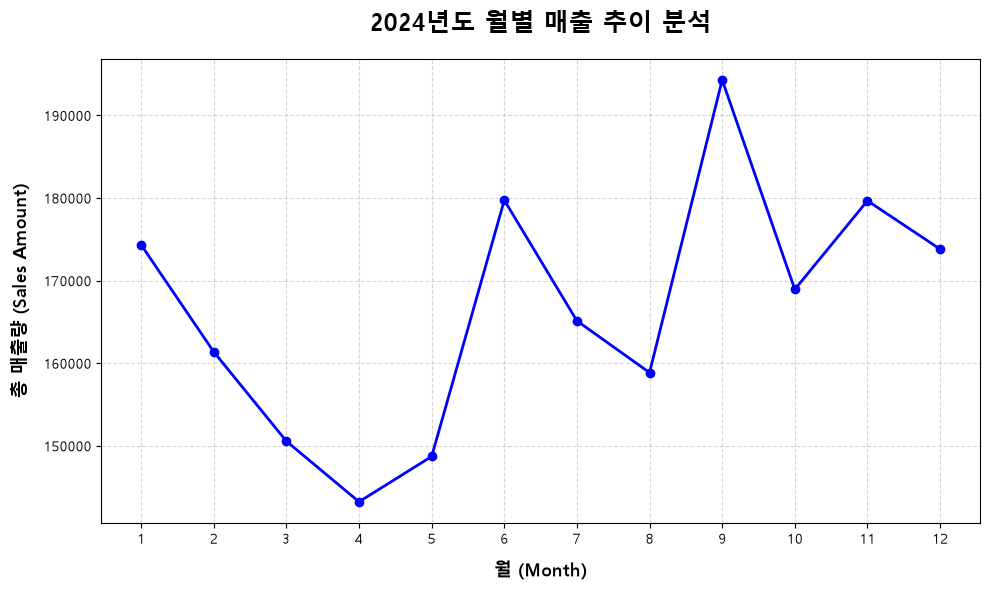

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class SalesAnalysis:
    def __init__(self):
        """
        [생성자] 2024년 연간 날짜 생성 및 일별 매출 난수 데이터 구축
        """
        # 1. 2024년 날짜 배열 생성 (윤년 반영 총 366일의 DatetimeIndex 생성)
        dates = pd.date_range(start='2024-01-01', end='2024-12-31')

        # 2. 1,000 이상 10,000 이하의 일별 매출 난수 생성 (10001로 지정해야 10000까지 포함됨)
        sales = np.random.randint(1000, 10001, size=len(dates))

        # 3. 생성된 날짜를 인덱스로 직접 지정하여 효율적인 시계열 데이터프레임 생성
        self.df = pd.DataFrame({'Sales': sales}, index=dates)


    def analyze_and_plot(self):
        """
        [분석 및 시각화] 월별 매출 총합 연산 및 꺾은선 그래프 시각화 출력
        """
        # 1. Datetime 인덱스의 '월(month)' 정보를 기준으로 그룹화하여 월별 매출 총합 계산
        monthly_sum = self.df.groupby(self.df.index.month).sum()

        # 2. 시각화 그래프 창 크기 설정 및 한글 폰트(맑은 고딕) 깨짐 방지 설정
        plt.figure(figsize=(10, 6))
        plt.rcParams['font.family'] = 'Malgun Gothic'
    
        # 3. 데이터 식별이 용이하도록 마커('o'), 선 두께(linewidth)를 추가한 꺾은선 그래프 그리기
        plt.plot(monthly_sum.index, monthly_sum['Sales'], marker='o', color='b', linewidth=2, label='월별 매출액')
        
        # 4. 평가 기준 맞춤형 타이틀 및 X/Y축 레이블 설정 (크기 및 굵기 강조)
        plt.title('2024년도 월별 매출 추이 분석', fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('월 (Month)', fontsize=13, fontweight='bold', labelpad=10)
        plt.ylabel('총 매출량 (Sales Amount)', fontsize=13, fontweight='bold', labelpad=10)
        
        # 5. X축 눈금을 1월부터 12월까지 직관적으로 표시
        plt.xticks(range(1, 13))
        
        # 6. 가독성을 높이기 위한 배경 그리드(보조선) 추가 (가산점 포인트)
        plt.grid(True, linestyle='--', alpha=0.5)
        
        # 7. 레이아웃 최적화 후 그래프 출력
        plt.tight_layout()
        plt.show()

# --- 클래스 실행 부분 ---
if __name__ == "__main__":
    # SalesAnalysis 객체 생성 (데이터 자동 초기화)
    analyzer = SalesAnalysis()

    # 분석 및 시각화 메서드 호출
    analyzer.analyze_and_plot()